# Project 1 — Individual Fairness: Similar Risk, Similar Price

Group fairness (parity, equalized odds) asks whether *groups* are treated equally. **Individual fairness** asks a stricter question: do two policyholders with the *same predicted risk* pay the same price? This is a trending distinction in the fairness literature and regulation.

We bin policies by predicted claim frequency (risk deciles) and compare mean premiums across protected groups *inside each bin*. Any remaining spread is pricing that does not come from risk — it comes from other rating factors.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.load import load_claims
from src.models import fit_frequency_model, fit_severity_model
from src.fairness import add_predictions, individual_fairness

plt.rcParams["figure.dpi"] = 110
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

df = load_claims(ROOT / "data" / "sample_claims.csv")
freq = fit_frequency_model(df)
sev = fit_severity_model(df)
scored = add_predictions(df, freq, sev)

table = individual_fairness(scored, "predicted_frequency", "predicted_premium")
print(table.to_string(index=False))

        risk_bin  min_premium  max_premium  max_min_ratio
(0.0315, 0.0624]       154.69       162.96           1.05
(0.0624, 0.0754]       205.72       215.09           1.05
 (0.0754, 0.087]       248.99       262.67           1.05
 (0.087, 0.0999]       296.37       313.40           1.06
 (0.0999, 0.114]       356.73       367.31           1.03
   (0.114, 0.13]       414.61       450.13           1.09
    (0.13, 0.15]       493.93       525.23           1.06
   (0.15, 0.177]       597.65       646.11           1.08
  (0.177, 0.218]       760.72       792.23           1.04
  (0.218, 0.533]      1230.65      1241.99           1.01


## The same-risk gap, visualized

For each risk decile, the two lines are the mean premium paid by F and M policyholders with the *same predicted risk*. The vertical gap is the price of non-risk factors.

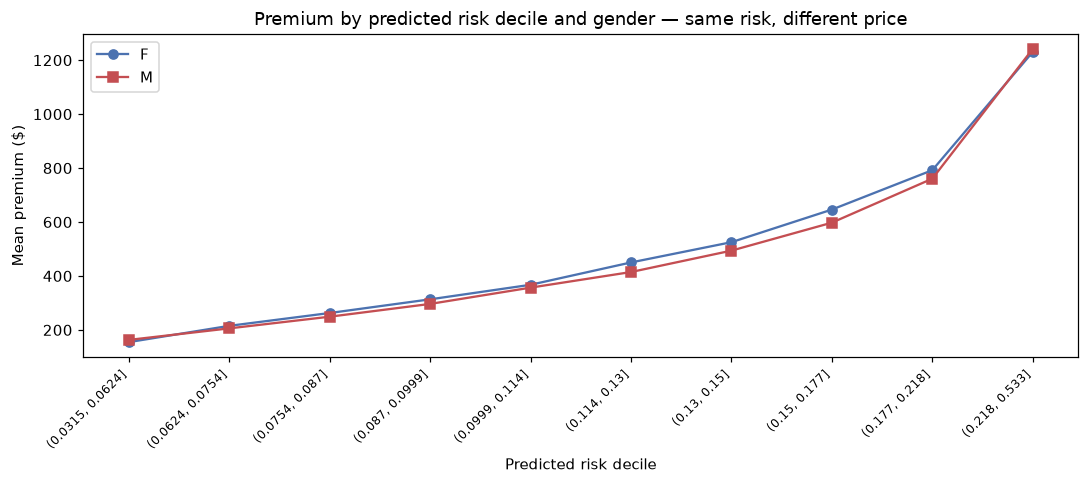

In [2]:
scored["risk_bin"] = pd.qcut(scored["predicted_frequency"], q=10, duplicates="drop")
by_bin = scored.groupby(["risk_bin", "gender"], observed=True)["predicted_premium"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(by_bin))
ax.plot(x, by_bin["F"], "o-", label="F", color="#4C72B0")
ax.plot(x, by_bin["M"], "s-", label="M", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in by_bin.index], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Predicted risk decile")
ax.set_ylabel("Mean premium ($)")
ax.set_title("Premium by predicted risk decile and gender — same risk, different price")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "individual_fairness.png", dpi=150)
plt.show()

## What this adds

* **Group fairness** (notebooks 03–04): equalize *average* outcomes across groups — a regulatory lens.
* **Individual fairness**: equal price for equal risk — a consumer-protection lens. The two can conflict: a policy that equalizes group means can still leave same-risk individuals paying different prices (and vice versa).
* On this synthetic data, the same-risk F/M premium gap is driven by **territory** (and gender) entering the premium. Removing gender from pricing (gender parity) narrows but does not eliminate it; removing territory as well would flatten it — at the accuracy cost measured in notebook 04.

**Extension path:** an individual-fairness constraint (e.g., bound the within-risk-bin premium ratio) is a natural next optimization, complementing the group-level frontier.